# 국토교통부_폭염 취약계층 및 지원 우선 지역 분석_에너지바우처 지원대책
- 링크: `https://www.data.go.kr/data/15134925/fileData.do?recommendDataYn=Y#`
- 라이센스: `공공저작물 : 출처표시, 변경금지 (제 3유형)`
- 데이터 저장 위치(로컬): [../../resource/datasets/ANALYSIS_OF_HEATWAVE_VULNERABLE_GROUPS_AND_PRIORITY_SUPPORT_AREAS_ENERGY_VOUCHER_SUPPORT_MEASURES/](../../resource/datasets/ANALYSIS_OF_HEATWAVE_VULNERABLE_GROUPS_AND_PRIORITY_SUPPORT_AREAS_ENERGY_VOUCHER_SUPPORT_MEASURES/)
- 데이터 타입: `SHP(ShapeFile)`
- 공간 제약: `대한민국 서울시`

In [ ]:
import geopandas as gpd
from pathlib import Path
import pandas as pd

shp_path = (Path() / ".." / ".." / "resource" / "datasets" / "ANALYSIS_OF_HEATWAVE_VULNERABLE_GROUPS_AND_PRIORITY_SUPPORT_AREAS_ENERGY_VOUCHER_SUPPORT_MEASURES" / "07_2023_폭염 취약계층 및 지원 우선 지역 분석_에너지바우처 지원대책.shp")

print(shp_path)

gdf = gpd.read_file(
    shp_path,
    encoding="utf-8"
)
# print(gdf.head())
# print(list(gdf.columns)[:6]) # 중복 이름의 컬럼중에서 첫번째로 나오는게 원점수
# print(list(gdf.columns)[6:]) # 중복 이름의 두번째가 점수(정규화 약 0 ~ 10)

SOURCE_COLUMNS = [
    "EMD_NM",
    "OLD_POP",
    "CHLD_POP",
    "CLCNTR_DST",
    "HSPTL_DST",
    "OLD_BLD_RT",
    "TMP_DSTRB",
    "OLD_POP_SC",
    "CHLD_POP_S",
    "CLCNTR_DST",
    "HSPTL_DST_",
    "OLD_BLD_RT",
    "TMP_DSTRB_",
    "ENRG_EFFCT",
    "ENRG_VCH_S",
    "MDCL_INSTT",
    "CLCNTR_SCR",
    "SGG_NM",
    "geometry",
]

if list(gdf.columns) != SOURCE_COLUMNS:
    raise ValueError(
        "예상한 원본 컬럼 구조와 다릅니다.\n"
        f"현재 컬럼: {list(gdf.columns)}"
    )
TARGET_COLUMNS = [
    "EMD_NM",
    "OLD_POP",
    "CHLD_POP",
    "CLCNTR_DST",
    "HSPTL_DST",
    "OLD_BLD_RT",
    "TMP_DSTRB",
    "OLD_POP_SCR",
    "CHLD_POP_SCR",
    "CLCNTR_DST_SCR",
    "HSPTL_DST_SCR",
    "OLD_BLD_RT_SCR",
    "TMP_DSTRB_SCR",
    "ENRG_EFFCT_SCR",
    "ENRG_VCH_SCR",
    "MDCL_INSTT_SCR",
    "CLCNTR_SCR",
    "SGG_NM",
    "geometry",
]

gdf.columns = TARGET_COLUMNS

numeric_columns = [
  "OLD_BLD_RT",
  "TMP_DSTRB",
]

for column in numeric_columns:
  gdf[column] = pd.to_numeric(gdf[column], errors="coerce")

pd.DataFrame({
  "순번": range(len(SOURCE_COLUMNS)),
  "원본 컬럼명": SOURCE_COLUMNS,
  "변경 컬럼명": TARGET_COLUMNS,
})
#columns = list(gdf.columns)

# columns[7] = "OLD_POP_SCR"
# columns[8] = "CHLD_POP_SCR"
# columns[10] = "HSPTL_DST_SCR" # 병원 거리까지 점수
# columns[11] = "OLD_BLD_RT_SCR" # 이름이 중복되는 두 컬럼 OLD_BLD_RT_SCR([5], [11])중에 5는 원점수, 11은 점수화
# columns[12] = "TMP_DSTRB_SCR" # 기온 열 분포 점수
# columns[12] = "ENRG_EFFCT_SCR" # 에너지 효과 점수
# columns[13] = "ENRG_VCH_SCR" # 에너지 바우처 점수

# gdf.rename(columns=columns)


# 한글이 깨지면 인코딩을 지정합니다.
# gdf.describe()

..\..\resource\datasets\ANALYSIS_OF_HEATWAVE_VULNERABLE_GROUPS_AND_PRIORITY_SUPPORT_AREAS_ENERGY_VOUCHER_SUPPORT_MEASURES\07_2023_폭염 취약계층 및 지원 우선 지역 분석_에너지바우처 지원대책.shp


,순번,원본 컬럼명,변경 컬럼명
0,0,EMD_NM,EMD_NM
1,1,OLD_POP,OLD_POP
2,2,CHLD_POP,CHLD_POP
3,3,CLCNTR_DST,CLCNTR_DST
4,4,HSPTL_DST,HSPTL_DST
5,5,OLD_BLD_RT,OLD_BLD_RT
6,6,TMP_DSTRB,TMP_DSTRB
7,7,OLD_POP_SC,OLD_POP_SCR
8,8,CHLD_POP_S,CHLD_POP_SCR
9,9,CLCNTR_DST,CLCNTR_DST_SCR


In [37]:
COLUMN_MAP = {
    "EMD_NM": "읍면동명",
    "OLD_POP": "고령 인구",
    "CHLD_POP": "아동 인구",
    "CLCNTR_DST": "무더위쉼터 거리",
    "HSPTL_DST": "병원 거리",
    "OLD_BLD_RT": "노후 건축물 비율",
    "TMP_DSTRB": "기온/열 분포",
    "OLD_POP_SCR": "고령 인구 점수",
    "CHLD_POP_SCR": "아동 인구 점수",
    "CLCNTR_DST_SCR": "무더위쉼터 거리 점수",
    "HSPTL_DST_SCR": "병원 거리 점수",
    "OLD_BLD_RT_SCR": "노후 건축물 비율 점수",
    "TMP_DSTRB_SCR": "기온/열 분포 점수",
    "ENRG_EFFCT_SCR": "에너지 영향/효과 점수",
    "ENRG_VCH_SCR": "에너지바우처 점수",
    "MDCL_INSTT_SCR": "의료기관 관련 값",
    "CLCNTR_SCR": "무더위쉼터 점수",
    "SGG_NM": "시군구명",
    "geometry": "공간 도형",
}

In [38]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 26994 entries, 0 to 26993
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   EMD_NM          26994 non-null  str     
 1   OLD_POP         26994 non-null  int64   
 2   CHLD_POP        26994 non-null  int64   
 3   CLCNTR_DST      26994 non-null  float64 
 4   HSPTL_DST       26994 non-null  float64 
 5   OLD_BLD_RT      26994 non-null  float64 
 6   TMP_DSTRB       26933 non-null  float64 
 7   OLD_POP_SCR     26994 non-null  float64 
 8   CHLD_POP_SCR    26994 non-null  float64 
 9   CLCNTR_DST_SCR  26994 non-null  float64 
 10  HSPTL_DST_SCR   26994 non-null  float64 
 11  OLD_BLD_RT_SCR  26994 non-null  float64 
 12  TMP_DSTRB_SCR   26994 non-null  float64 
 13  ENRG_EFFCT_SCR  26994 non-null  float64 
 14  ENRG_VCH_SCR    26994 non-null  float64 
 15  MDCL_INSTT_SCR  26994 non-null  float64 
 16  CLCNTR_SCR      26994 non-null  float64 
 17  SGG_

In [41]:
# gdf[gdf["TMP_DSTRB_SCR"] == 0][["TMP_DSTRB", "TMP_DSTRB_SCR"]]
gdf[gdf["TMP_DSTRB"].isna()][["TMP_DSTRB", "TMP_DSTRB_SCR"]]

,TMP_DSTRB,TMP_DSTRB_SCR
11,NaN,0.0
45,NaN,0.0
101,NaN,0.0
705,NaN,0.0
845,NaN,0.0
...,...,...
25358,NaN,0.0
25395,NaN,0.0
26045,NaN,0.0
26050,NaN,0.0


In [ ]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

- `EPSG:4326 / WGS 84` = 위도/경도 좌표계 (단위가 `도`)
- `Geographic 2D`: 지리 좌표계

In [47]:
# 한글 폰트 사용을 위한 고딕 설정
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

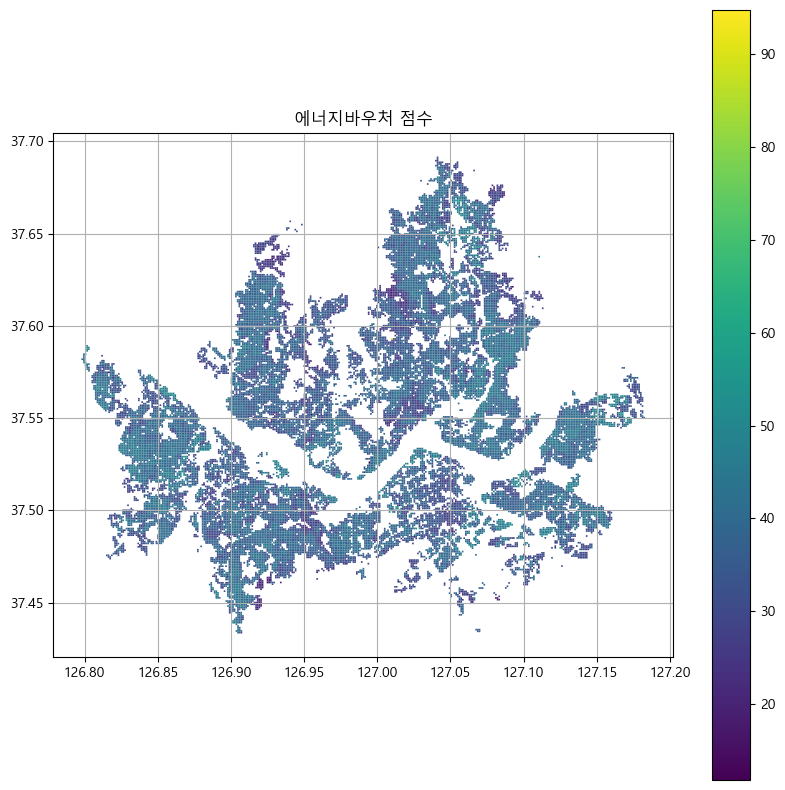

In [49]:

title = COLUMN_MAP.get("ENRG_VCH_SCR", "ENRG_VCH_SCR")
ax = gdf.plot(column="ENRG_VCH_SCR", legend=True, figsize=(10, 10))

ax.set_title(title)
# 그래프의 좌표축을 숨기는 명령어
# ax.set_axis_off()
ax.grid(True)

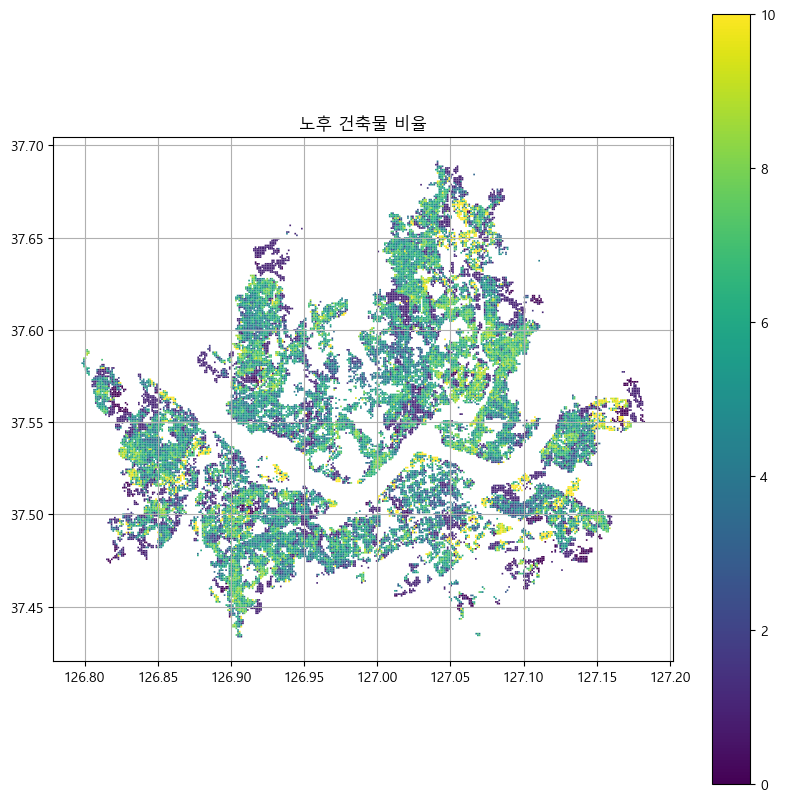

In [50]:
title = COLUMN_MAP.get("OLD_BLD_RT", "OLD_BLD_RT")
ax = gdf.plot(column="OLD_BLD_RT", legend=True, figsize=(10, 10))

ax.set_title(title)
# 그래프의 좌표축을 숨기는 명령어
# ax.set_axis_off()
ax.grid(True)